# 05 — Full S&P 500 Training

Scale the ML pipeline from 5 test stocks to all ~500 S&P 500 constituents.

**Pipeline:** Fetch S&P 500 list → batch download 5y OHLCV → compute 19 features → label with future returns → check class distribution → time-based split → train XGBoost (3 models) → evaluate → save.

**Expected improvements over 5-stock baseline:**
- ~100x more training data → better generalization
- Diverse sectors → more balanced class distribution
- Three horizon-specific models (3m, 6m, 1y)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
import joblib
import os
import requests
from io import StringIO
from collections import Counter
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, mean_absolute_error
)
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_style("whitegrid")

## 1. Fetch S&P 500 Ticker List

Pull the current S&P 500 constituents from Wikipedia (same source as notebook 01).

In [2]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "StockPredictor/1.0 (bachelor thesis project)"}
response = requests.get(url, headers=headers)

sp500_table = pd.read_html(StringIO(response.text))[0]
sp500_tickers = sp500_table["Symbol"].str.replace(".", "-", regex=False).tolist()

print(f"Total S&P 500 tickers: {len(sp500_tickers)}")
print(f"\nSector distribution:")
print(sp500_table["GICS Sector"].value_counts().to_string())
print(f"\nFirst 10: {sp500_tickers[:10]}")

Total S&P 500 tickers: 503

Sector distribution:
GICS Sector
Industrials               79
Financials                76
Information Technology    71
Health Care               60
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22

First 10: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


## 2. Batch Download Data

Download 5 years of OHLCV data for all S&P 500 stocks.

- **Batch size:** 50 tickers per request to avoid rate limiting
- **Delay:** 2 seconds between batches
- **Minimum data:** 504 rows (~2 years) required — enough for feature warm-up (252 days) plus 1-year forward labels
- **Error handling:** log and skip failed tickers without crashing

In [3]:
BATCH_SIZE = 50
MIN_ROWS = 504

batches = [sp500_tickers[i:i + BATCH_SIZE] for i in range(0, len(sp500_tickers), BATCH_SIZE)]
n_batches = len(batches)

all_data = {}
failed_tickers = []

print(f"Downloading {len(sp500_tickers)} tickers in {n_batches} batches of {BATCH_SIZE}...\n")

for batch_num, batch in enumerate(batches, 1):
    print(f"Batch {batch_num}/{n_batches}: downloading {len(batch)} tickers...")

    try:
        raw = yf.download(batch, period="5y", group_by="ticker", auto_adjust=True)

        for ticker in batch:
            try:
                df = raw[ticker].copy()
                df = df.dropna(how="all")

                if len(df) < MIN_ROWS:
                    failed_tickers.append((ticker, f"insufficient data: {len(df)} rows"))
                    continue

                all_data[ticker] = df

            except KeyError:
                failed_tickers.append((ticker, "not found in download"))
            except Exception as e:
                failed_tickers.append((ticker, str(e)[:80]))

    except Exception as e:
        print(f"  Batch {batch_num} failed: {e}")
        for t in batch:
            failed_tickers.append((t, f"batch error: {str(e)[:50]}"))

    if batch_num < n_batches:
        time.sleep(2)

print(f"\nDownload complete!")


Batch 1/11: downloading 50 tickers...


[*********************100%***********************]  50 of 50 completed


Batch 2/11: downloading 50 tickers...


[*********************100%***********************]  50 of 50 completed


Batch 3/11: downloading 50 tickers...


...

Batch 10/11: downloading 50 tickers...


[*********************100%***********************]  50 of 50 completed


Batch 11/11: downloading 3 tickers...


[*********************100%***********************]  3 of 3 completed


Download complete!


In [4]:
print(f"{'='*50}")
print(f"Download Summary")
print(f"{'='*50}")
print(f"Attempted: {len(sp500_tickers)}")
print(f"Succeeded: {len(all_data)}")
print(f"Failed:    {len(failed_tickers)}")

if failed_tickers:
    print(f"\nFailed tickers:")
    for ticker, reason in failed_tickers:
        print(f"  {ticker}: {reason}")

rows_per_ticker = [len(df) for df in all_data.values()]
print(f"\nRows per ticker: min={min(rows_per_ticker)}, max={max(rows_per_ticker)}, median={np.median(rows_per_ticker):.0f}")

Download Summary
Attempted: 503
Succeeded: 499
Failed:    4

Failed tickers:
  GEV: insufficient data: 498 rows
  Q: insufficient data: 101 rows
  SNDK: insufficient data: 277 rows
  SOLV: insufficient data: 499 rows

Rows per ticker: min=618, max=1255, median=1255


## 3. Reusable Functions & Constants

Same functions from notebooks 02–04: feature computation, future returns, signal assignment.

In [5]:
HORIZONS = {"3m": 63, "6m": 126, "1y": 252}

THRESHOLDS = {
    "3m": (-8, -3, 3, 8),
    "6m": (-12, -4, 5, 12),
    "1y": (-15, -5, 8, 20),
}

SIGNAL_LABELS = ["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"]

FEATURE_COLS = [
    "Price_SMA50_Ratio", "Price_SMA200_Ratio", "Price_EMA20_Ratio",
    "MACD_Norm", "MACD_Signal_Norm", "MACD_Hist_Norm",
    "RSI", "Stoch_K", "Stoch_D", "ROC",
    "BB_Position", "BB_Width", "ATR_Pct",
    "OBV_Norm", "Vol_SMA_Ratio",
    "Dist_52w_High", "Dist_52w_Low", "Return_1m", "Return_3m",
]


def compute_features(df: pd.DataFrame) -> pd.DataFrame:
    """Compute all technical indicators on a DataFrame with OHLCV columns.

    All features are relative (ratios, percentages, bounded scales) so they
    generalize across stocks at different price levels.
    """
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # --- Trend (ratios around 1.0) ---
    sma_50 = df["Close"].rolling(window=50).mean()
    sma_200 = df["Close"].rolling(window=200).mean()
    ema_20 = df["Close"].ewm(span=20, adjust=False).mean()
    df["Price_SMA50_Ratio"] = df["Close"] / sma_50
    df["Price_SMA200_Ratio"] = df["Close"] / sma_200
    df["Price_EMA20_Ratio"] = df["Close"] / ema_20

    ema_12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema_26 = df["Close"].ewm(span=26, adjust=False).mean()
    macd_raw = ema_12 - ema_26
    macd_signal_raw = macd_raw.ewm(span=9, adjust=False).mean()
    df["MACD_Norm"] = macd_raw / df["Close"] * 100
    df["MACD_Signal_Norm"] = macd_signal_raw / df["Close"] * 100
    df["MACD_Hist_Norm"] = df["MACD_Norm"] - df["MACD_Signal_Norm"]

    # --- Momentum ---
    delta = df["Close"].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    rs = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + rs))

    low_14 = df["Low"].rolling(window=14).min()
    high_14 = df["High"].rolling(window=14).max()
    df["Stoch_K"] = 100 * (df["Close"] - low_14) / (high_14 - low_14)
    df["Stoch_D"] = df["Stoch_K"].rolling(window=3).mean()
    df["ROC"] = df["Close"].pct_change(periods=21) * 100

    # --- Volatility (relative) ---
    bb_sma = df["Close"].rolling(window=20).mean()
    bb_std = df["Close"].rolling(window=20).std()
    bb_upper = bb_sma + 2 * bb_std
    bb_lower = bb_sma - 2 * bb_std
    df["BB_Position"] = (df["Close"] - bb_lower) / (bb_upper - bb_lower)
    df["BB_Width"] = (bb_upper - bb_lower) / bb_sma

    high_low = df["High"] - df["Low"]
    high_close = (df["High"] - df["Close"].shift(1)).abs()
    low_close = (df["Low"] - df["Close"].shift(1)).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df["ATR_Pct"] = true_range.rolling(window=14).mean() / df["Close"] * 100

    # --- Volume (relative) ---
    obv_sign = np.sign(df["Close"].diff())
    obv = (obv_sign * df["Volume"]).cumsum()
    df["OBV_Norm"] = obv.diff(21) / df["Volume"].rolling(21).mean()
    df["Vol_SMA_Ratio"] = df["Volume"] / df["Volume"].rolling(window=20).mean()

    # --- Price-derived (percentages) ---
    high_252 = df["High"].rolling(window=252).max()
    low_252 = df["Low"].rolling(window=252).min()
    df["Dist_52w_High"] = (df["Close"] - high_252) / high_252 * 100
    df["Dist_52w_Low"] = (df["Close"] - low_252) / low_252 * 100
    df["Return_1m"] = df["Close"].pct_change(periods=21) * 100
    df["Return_3m"] = df["Close"].pct_change(periods=63) * 100

    return df


def compute_future_returns(close: pd.Series, horizon_days: int) -> pd.Series:
    return (close.shift(-horizon_days) / close - 1) * 100


def assign_signal(returns: pd.Series, thresholds: tuple) -> pd.Series:
    ss, s, b, sb = thresholds
    conditions = [
        returns < ss,
        (returns >= ss) & (returns < s),
        (returns >= s) & (returns < b),
        (returns >= b) & (returns < sb),
        returns >= sb,
    ]
    return pd.Series(
        np.select(conditions, SIGNAL_LABELS, default=""),
        index=returns.index,
    ).replace("", np.nan)

print(f"Functions loaded. {len(FEATURE_COLS)} features defined.")

Functions loaded. 19 features defined.


## 4. Compute Features & Labels

Apply feature engineering to all stocks, then compute signal labels for each horizon.

In [6]:
# Step 1: compute features for every ticker
print(f"Computing features for {len(all_data)} tickers...\n")

processed = {}
feature_errors = []

for i, (ticker, df) in enumerate(all_data.items(), 1):
    try:
        processed[ticker] = compute_features(df)
    except Exception as e:
        feature_errors.append((ticker, str(e)[:80]))

    if i % 100 == 0 or i == len(all_data):
        print(f"  Progress: {i}/{len(all_data)} tickers processed")

print(f"\nFeatures computed: {len(processed)} succeeded, {len(feature_errors)} failed")
if feature_errors:
    print(f"Feature errors: {feature_errors}")

# Free raw download data
del all_data

# Step 2: build labeled datasets per horizon
horizon_dfs = {}

for horizon_name, horizon_days in HORIZONS.items():
    datasets = []
    for ticker, df in processed.items():
        future_ret = compute_future_returns(df["Close"], horizon_days)
        signals = assign_signal(future_ret, THRESHOLDS[horizon_name])
        subset = df[FEATURE_COLS].copy()
        subset["Signal"] = signals
        subset["Ticker"] = ticker
        subset = subset.dropna(subset=FEATURE_COLS + ["Signal"])
        if len(subset) > 0:
            datasets.append(subset)

    horizon_dfs[horizon_name] = pd.concat(datasets)
    hdf = horizon_dfs[horizon_name]
    print(f"\n{horizon_name}: {len(hdf):,} samples from {hdf['Ticker'].nunique()} tickers")
    print(f"  Date range: {hdf.index.min().date()} to {hdf.index.max().date()}")

Computing features for 499 tickers...

  Progress: 100/499 tickers processed
  Progress: 200/499 tickers processed
  Progress: 300/499 tickers processed
  Progress: 400/499 tickers processed
  Progress: 499/499 tickers processed

Features computed: 499 succeeded, 0 failed

3m: 467,627 samples from 499 tickers
  Date range: 2022-03-22 to 2025-12-18

6m: 436,190 samples from 499 tickers
  Date range: 2022-03-22 to 2025-09-19

1y: 373,316 samples from 499 tickers
  Date range: 2022-03-22 to 2025-03-20


## 5. Class Distribution Analysis

**CRITICAL CHECKPOINT** — Review the distribution before proceeding to training.

Rule from CLAUDE.md: **no class below 12% or above 30%**. With 5 test stocks, Strong Buy was 36–39% because all 5 were bull-market winners. With ~500 diverse stocks we expect better balance.


3m Horizon — Class Distribution
   Strong Sell: 96,335 ( 20.6%)
          Sell: 58,574 ( 12.5%)
          Hold: 82,524 ( 17.6%)
           Buy: 66,721 ( 14.3%)
    Strong Buy: 163,473 ( 35.0%) << ABOVE 30%

6m Horizon — Class Distribution
   Strong Sell: 68,473 ( 15.7%)
          Sell: 58,560 ( 13.4%)
          Hold: 85,168 ( 19.5%)
           Buy: 65,013 ( 14.9%)
    Strong Buy: 158,976 ( 36.4%) << ABOVE 30%

1y Horizon — Class Distribution
   Strong Sell: 52,038 ( 13.9%)
          Sell: 44,680 ( 12.0%) << BELOW 12%
          Hold: 70,611 ( 18.9%)
           Buy: 64,979 ( 17.4%)
    Strong Buy: 141,008 ( 37.8%) << ABOVE 30%


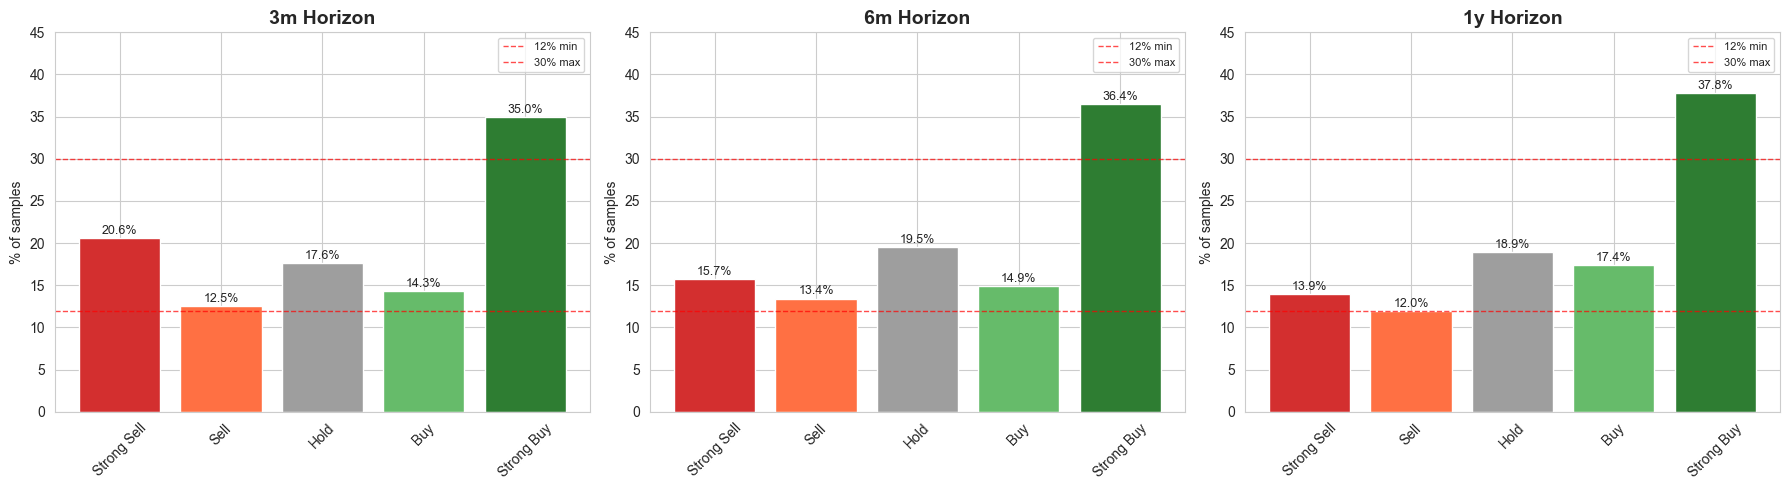


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
THRESHOLD VIOLATIONS DETECTED — adjustment may be needed!
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  3m: Strong Buy is 35.0% (above limit)
  6m: Strong Buy is 36.4% (above limit)
  1y: Sell is 12.0% (below limit)
  1y: Strong Buy is 37.8% (above limit)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ["#d32f2f", "#ff7043", "#9e9e9e", "#66bb6a", "#2e7d32"]

violations = {}

for idx, horizon_name in enumerate(HORIZONS):
    hdf = horizon_dfs[horizon_name]
    counts = hdf["Signal"].value_counts().reindex(SIGNAL_LABELS)
    pcts = counts / counts.sum() * 100

    bars = axes[idx].bar(SIGNAL_LABELS, pcts, color=colors)
    axes[idx].set_title(f"{horizon_name} Horizon", fontsize=14, fontweight="bold")
    axes[idx].set_ylabel("% of samples")
    axes[idx].set_ylim(0, 45)
    axes[idx].axhline(y=12, color="red", linestyle="--", linewidth=1, alpha=0.7, label="12% min")
    axes[idx].axhline(y=30, color="red", linestyle="--", linewidth=1, alpha=0.7, label="30% max")
    axes[idx].tick_params(axis="x", rotation=45)
    axes[idx].legend(fontsize=8)

    for bar, pct in zip(bars, pcts):
        axes[idx].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                       f"{pct:.1f}%", ha="center", fontsize=9)

    horizon_violations = []
    print(f"\n{'='*50}")
    print(f"{horizon_name} Horizon — Class Distribution")
    print(f"{'='*50}")
    for label, count, pct in zip(SIGNAL_LABELS, counts, pcts):
        flag = ""
        if pct < 12:
            flag = " << BELOW 12%"
            horizon_violations.append((label, pct, "below"))
        elif pct > 30:
            flag = " << ABOVE 30%"
            horizon_violations.append((label, pct, "above"))
        print(f"  {label:>12}: {int(count):6,} ({pct:5.1f}%){flag}")

    if horizon_violations:
        violations[horizon_name] = horizon_violations

plt.tight_layout()
plt.show()

if violations:
    print("\n" + "!"*60)
    print("THRESHOLD VIOLATIONS DETECTED — adjustment may be needed!")
    print("!"*60)
    for h, v in violations.items():
        for label, pct, direction in v:
            print(f"  {h}: {label} is {pct:.1f}% ({direction} limit)")
else:
    print("\nAll classes within 12-30% range. No threshold adjustment needed.")


3m return percentiles:
  P10: -14.5%
  P15: -11.2%
  P20: -8.6%
  P30: -4.4%
  P50: +2.4%
  P70: +9.4%
  P80: +14.0%
  P85: +16.9%
  P90: +21.0%

6m return percentiles:
  P10: -18.8%
  P15: -14.2%
  P20: -10.6%
  P30: -4.9%
  P50: +4.4%
  P70: +14.2%
  P80: +20.7%
  P85: +25.0%
  P90: +31.1%

1y return percentiles:
  P10: -23.8%
  P15: -18.2%
  P20: -13.6%
  P30: -6.0%
  P50: +7.4%
  P70: +22.0%
  P80: +32.5%
  P85: +40.1%
  P90: +51.0%


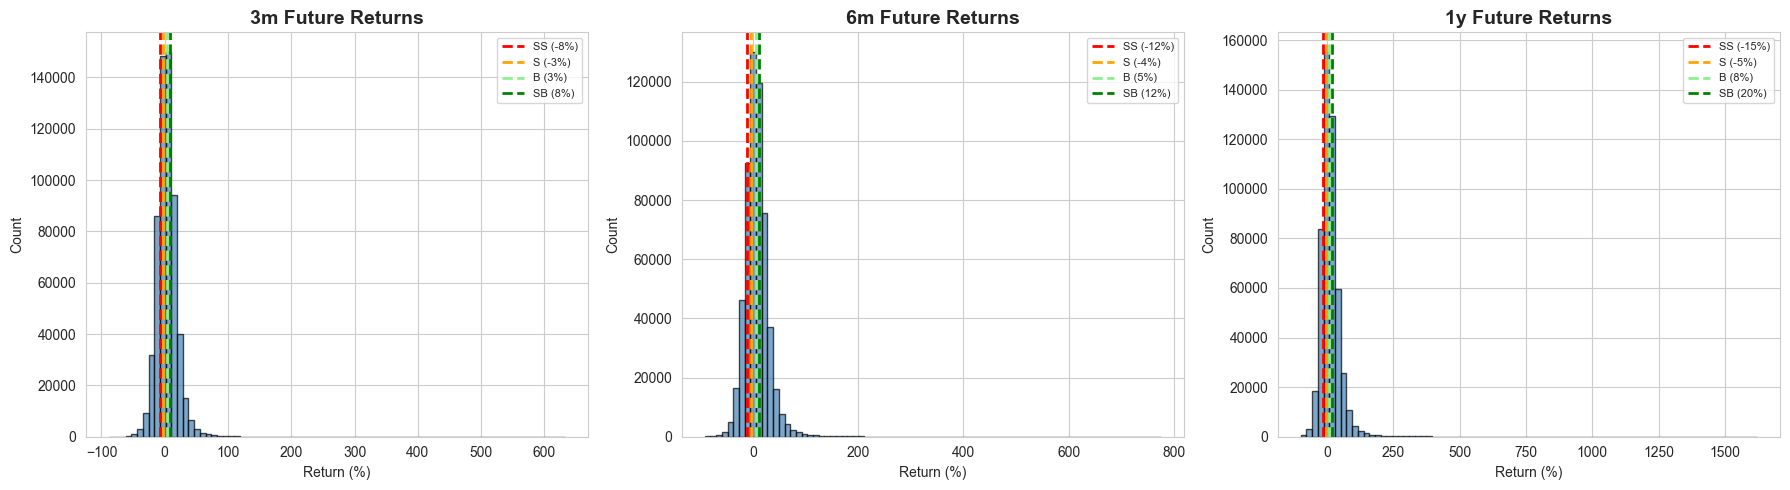

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (horizon_name, horizon_days) in enumerate(HORIZONS.items()):
    all_returns = []
    for ticker, df in processed.items():
        future_ret = compute_future_returns(df["Close"], horizon_days).dropna()
        all_returns.append(future_ret)

    combined_returns = pd.concat(all_returns)

    axes[idx].hist(combined_returns, bins=80, edgecolor="black", alpha=0.7, color="steelblue")

    ss, s, b, sb = THRESHOLDS[horizon_name]
    for thresh, color, label in [
        (ss, "red", f"SS ({ss}%)"), (s, "orange", f"S ({s}%)"),
        (b, "lightgreen", f"B ({b}%)"), (sb, "green", f"SB ({sb}%)")
    ]:
        axes[idx].axvline(x=thresh, color=color, linestyle="--", linewidth=2, label=label)

    axes[idx].set_title(f"{horizon_name} Future Returns", fontsize=14, fontweight="bold")
    axes[idx].set_xlabel("Return (%)")
    axes[idx].set_ylabel("Count")
    axes[idx].legend(fontsize=8)

    # Print percentiles for threshold guidance
    percentiles = [10, 15, 20, 30, 50, 70, 80, 85, 90]
    pvals = np.percentile(combined_returns, percentiles)
    print(f"\n{horizon_name} return percentiles:")
    for p, v in zip(percentiles, pvals):
        print(f"  P{p}: {v:+.1f}%")

plt.tight_layout()
plt.show()

## 5b. Threshold Adjustment (If Needed)

If any class violated the 12–30% rule above, adjust the thresholds below.

**How to use:**
1. Look at the percentile values and histograms above
2. Uncomment the `THRESHOLDS` dict below and set new boundary values
3. Set `THRESHOLDS_CHANGED = True`
4. Run this cell — it will recompute labels and show the updated distribution

In [13]:
# ============================================================
# THRESHOLD ADJUSTMENT
# ============================================================
# Uncomment and modify the thresholds if the distribution
# check above showed violations. Use the percentile values
# as guidance — aim for each class between 12-30%.

THRESHOLDS = {
     "3m": (-10, -3, 3, 12),      # original
     "6m": (-12, -4, 5, 18),    # original
     "1y": (-15, -3, 10, 30),    # original
 }

THRESHOLDS_CHANGED = True 

if THRESHOLDS_CHANGED:
    print("Re-computing labels with updated thresholds...\n")
    for horizon_name, horizon_days in HORIZONS.items():
        datasets = []
        for ticker, df in processed.items():
            future_ret = compute_future_returns(df["Close"], horizon_days)
            signals = assign_signal(future_ret, THRESHOLDS[horizon_name])
            subset = df[FEATURE_COLS].copy()
            subset["Signal"] = signals
            subset["Ticker"] = ticker
            subset = subset.dropna(subset=FEATURE_COLS + ["Signal"])
            if len(subset) > 0:
                datasets.append(subset)

        horizon_dfs[horizon_name] = pd.concat(datasets)
        hdf = horizon_dfs[horizon_name]
        counts = hdf["Signal"].value_counts().reindex(SIGNAL_LABELS)
        pcts = counts / counts.sum() * 100

        print(f"{horizon_name}:")
        for label, count, pct in zip(SIGNAL_LABELS, counts, pcts):
            ok = "ok" if 12 <= pct <= 30 else "!!"
            print(f"  {label:>12}: {int(count):6,} ({pct:5.1f}%) [{ok}]")
        print()

    print("Done! Continue to training.")
else:
    print("No threshold changes. Continuing with original thresholds.")

Re-computing labels with updated thresholds...

3m:
   Strong Sell: 77,444 ( 16.6%) [ok]
          Sell: 77,465 ( 16.6%) [ok]
          Hold: 82,524 ( 17.6%) [ok]
           Buy: 112,117 ( 24.0%) [ok]
    Strong Buy: 118,077 ( 25.3%) [ok]

6m:
   Strong Sell: 68,473 ( 15.7%) [ok]
          Sell: 58,560 ( 13.4%) [ok]
          Hold: 85,168 ( 19.5%) [ok]
           Buy: 111,781 ( 25.6%) [ok]
    Strong Buy: 112,208 ( 25.7%) [ok]

1y:
   Strong Sell: 52,038 ( 13.9%) [ok]
          Sell: 55,137 ( 14.8%) [ok]
          Hold: 71,379 ( 19.1%) [ok]
           Buy: 97,411 ( 26.1%) [ok]
    Strong Buy: 97,351 ( 26.1%) [ok]

Done! Continue to training.


## 6. Time-Based Train/Test Split

Split by date (NOT random) to prevent data leakage. The first 80% of trading dates go to training, the last 20% to testing. Each horizon gets its own split since the date ranges differ slightly.

In [15]:
splits = {}

le = LabelEncoder()
le.fit(SIGNAL_LABELS)

for horizon_name in HORIZONS:
    hdf = horizon_dfs[horizon_name]

    all_dates = hdf.index.unique().sort_values()
    split_idx = int(len(all_dates) * 0.8)
    split_date = all_dates[split_idx]

    train = hdf[hdf.index < split_date]
    test = hdf[hdf.index >= split_date]

    splits[horizon_name] = {
        "X_train": train[FEATURE_COLS],
        "X_test": test[FEATURE_COLS],
        "y_train": le.transform(train["Signal"]),
        "y_test": le.transform(test["Signal"]),
        "split_date": split_date,
        "train_df": train,
        "test_df": test,
    }

    # Verify no data leakage
    train_max = train.index.max()
    test_min = test.index.min()
    assert test_min > train_max, f"Data leakage! Train max: {train_max}, Test min: {test_min}"

    print(f"\n{'='*50}")
    print(f"{horizon_name} Horizon — Train/Test Split")
    print(f"{'='*50}")
    print(f"Split date: {split_date.date()}")
    print(f"Train: {len(train):,} samples ({train.index.min().date()} to {train.index.max().date()})")
    print(f"Test:  {len(test):,} samples ({test.index.min().date()} to {test.index.max().date()})")
    print(f"No leakage: verified (test starts after train ends)")

    print(f"\n  {'':>12} {'Train':>8} {'Test':>8}")
    print(f"  {'-'*30}")
    for i, label in enumerate(SIGNAL_LABELS):
        tr_pct = (splits[horizon_name]["y_train"] == i).sum() / len(splits[horizon_name]["y_train"]) * 100
        te_pct = (splits[horizon_name]["y_test"] == i).sum() / len(splits[horizon_name]["y_test"]) * 100
        print(f"  {label:>12} {tr_pct:7.1f}% {te_pct:7.1f}%")


3m Horizon — Train/Test Split
Split date: 2025-03-21
Train: 373,317 samples (2022-03-22 to 2025-03-20)
Test:  94,310 samples (2025-03-21 to 2025-12-18)
No leakage: verified (test starts after train ends)

                  Train     Test
  ------------------------------
   Strong Sell    24.1%    23.4%
          Sell    17.8%    17.1%
          Hold    16.8%    15.6%
           Buy    24.2%    29.5%
    Strong Buy    17.1%    14.3%

6m Horizon — Train/Test Split
Split date: 2025-01-07
Train: 348,367 samples (2022-03-22 to 2025-01-06)
Test:  87,823 samples (2025-01-07 to 2025-09-19)
No leakage: verified (test starts after train ends)

                  Train     Test
  ------------------------------
   Strong Sell    25.8%    24.9%
          Sell    19.7%    18.9%
          Hold    13.6%    12.9%
           Buy    25.3%    27.4%
    Strong Buy    15.7%    15.9%

1y Horizon — Train/Test Split
Split date: 2024-08-13
Train: 298,004 samples (2022-03-22 to 2024-08-12)
Test:  75,312 samples 

## 7. Train XGBoost for All 3 Horizons

One model per horizon using the same hyperparameters as the 5-stock baseline (notebook 04). Class weights via `sample_weight` to handle any remaining imbalance.

In [16]:
models = {}

for horizon_name in HORIZONS:
    print(f"\n{'='*50}")
    print(f"Training {horizon_name} model...")
    print(f"{'='*50}")

    s = splits[horizon_name]
    X_train, y_train = s["X_train"], s["y_train"]

    # Compute class weights to handle imbalance
    class_counts = Counter(y_train)
    total = len(y_train)
    n_classes = len(SIGNAL_LABELS)
    class_weights = {cls: total / (n_classes * count) for cls, count in class_counts.items()}
    sample_weights = np.array([class_weights[y] for y in y_train])

    print(f"Training samples: {len(X_train):,}")
    weights_str = ", ".join(f"{SIGNAL_LABELS[k]}={v:.2f}" for k, v in sorted(class_weights.items()))
    print(f"Class weights: {weights_str}")

    model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train, y_train, sample_weight=sample_weights)
    models[horizon_name] = model
    print(f"{horizon_name} model trained.")

print(f"\nAll 3 models trained successfully.")


Training 3m model...
Training samples: 373,317
Class weights: Strong Sell=0.83, Sell=1.12, Hold=1.19, Buy=0.83, Strong Buy=1.17
3m model trained.

Training 6m model...
Training samples: 348,367
Class weights: Strong Sell=0.77, Sell=1.02, Hold=1.48, Buy=0.79, Strong Buy=1.28
6m model trained.

Training 1y model...
Training samples: 298,004
Class weights: Strong Sell=0.75, Sell=1.04, Hold=1.41, Buy=0.74, Strong Buy=1.56
1y model trained.

All 3 models trained successfully.


## 8. Evaluate All 3 Models

For each horizon: weighted F1 (primary), accuracy, MAE on class index, per-class classification report.

In [17]:
results = {}

for horizon_name in HORIZONS:
    s = splits[horizon_name]
    model = models[horizon_name]

    y_pred = model.predict(s["X_test"])

    w_f1 = f1_score(s["y_test"], y_pred, average="weighted")
    acc = accuracy_score(s["y_test"], y_pred)
    mae = mean_absolute_error(s["y_test"], y_pred)

    results[horizon_name] = {
        "y_pred": y_pred,
        "weighted_f1": w_f1,
        "accuracy": acc,
        "mae": mae,
    }

    print(f"\n{'='*50}")
    print(f"{horizon_name} Horizon Results")
    print(f"{'='*50}")
    print(f"Weighted F1:  {w_f1:.4f}")
    print(f"Accuracy:     {acc:.4f}")
    print(f"MAE (class):  {mae:.4f}  (0 = perfect, 4 = worst)")
    print(f"\n{classification_report(s['y_test'], y_pred, target_names=SIGNAL_LABELS, zero_division=0)}")


3m Horizon Results
Weighted F1:  0.2632
Accuracy:     0.2603
MAE (class):  1.4215  (0 = perfect, 4 = worst)

              precision    recall  f1-score   support

 Strong Sell       0.28      0.18      0.22     22072
        Sell       0.23      0.24      0.24     16141
        Hold       0.19      0.17      0.18     14733
         Buy       0.40      0.35      0.38     27842
  Strong Buy       0.16      0.32      0.22     13522

    accuracy                           0.26     94310
   macro avg       0.26      0.25      0.25     94310
weighted avg       0.28      0.26      0.26     94310


6m Horizon Results
Weighted F1:  0.2486
Accuracy:     0.2427
MAE (class):  1.4642  (0 = perfect, 4 = worst)

              precision    recall  f1-score   support

 Strong Sell       0.29      0.18      0.23     21853
        Sell       0.25      0.22      0.24     16581
        Hold       0.16      0.24      0.19     11349
         Buy       0.38      0.30      0.34     24099
  Strong Buy       0

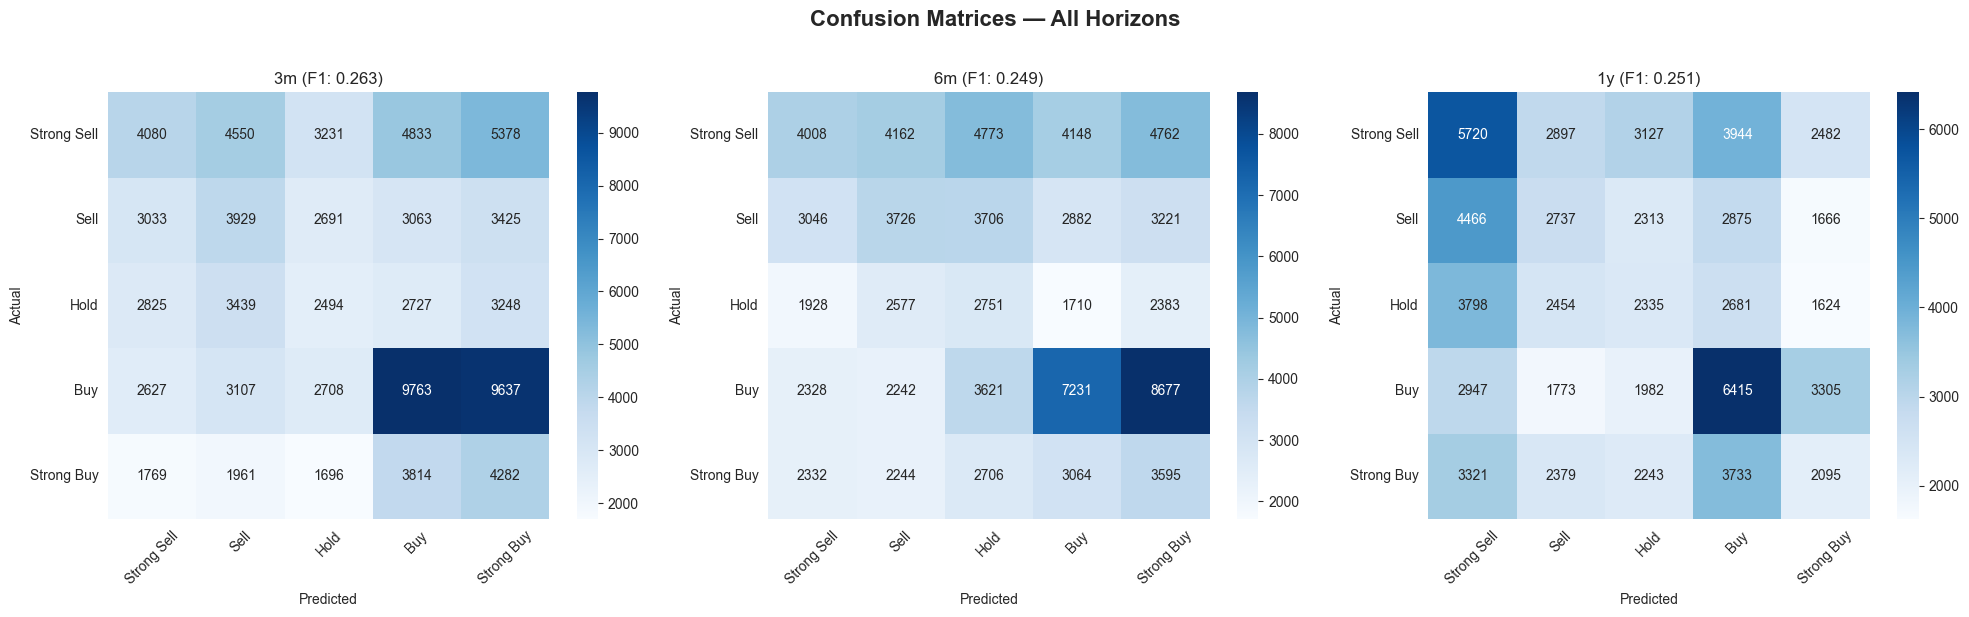

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, horizon_name in enumerate(HORIZONS):
    s = splits[horizon_name]
    y_pred = results[horizon_name]["y_pred"]

    cm = confusion_matrix(s["y_test"], y_pred)
    w_f1 = results[horizon_name]["weighted_f1"]

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=SIGNAL_LABELS, yticklabels=SIGNAL_LABELS, ax=axes[idx])
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")
    axes[idx].set_title(f"{horizon_name} (F1: {w_f1:.3f})")
    axes[idx].tick_params(axis="x", rotation=45)
    axes[idx].tick_params(axis="y", rotation=0)

plt.suptitle("Confusion Matrices — All Horizons", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

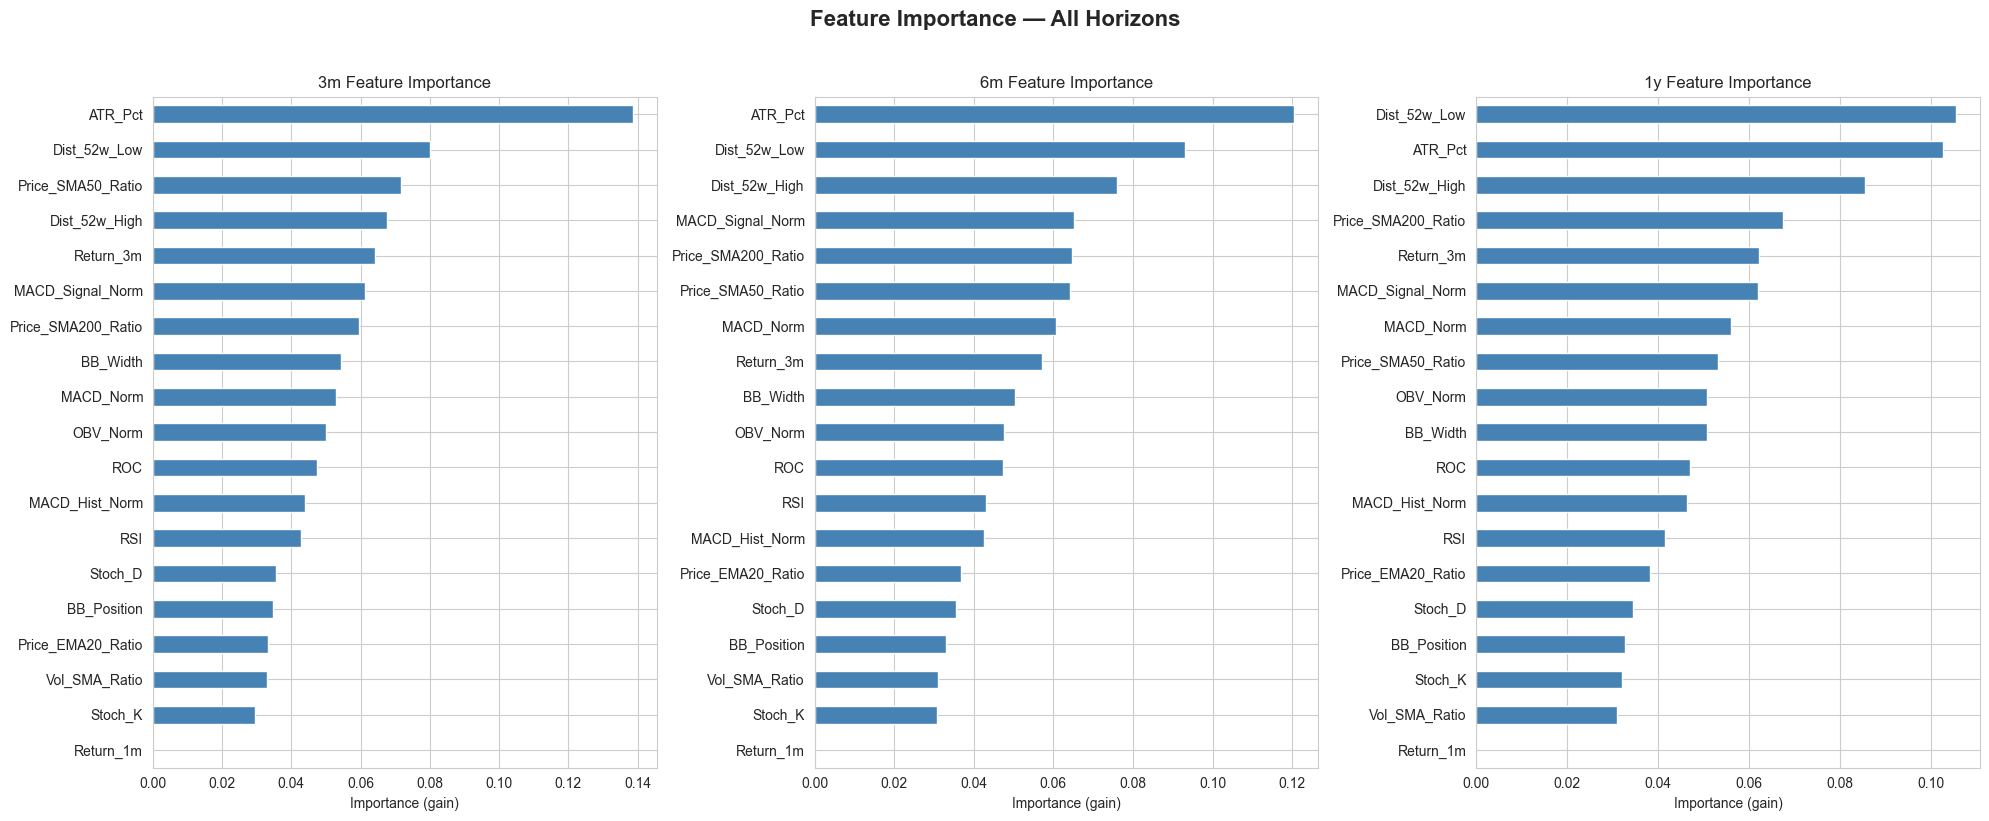


3m top 5 features:
  ATR_Pct: 0.1386
  Dist_52w_Low: 0.0799
  Price_SMA50_Ratio: 0.0715
  Dist_52w_High: 0.0677
  Return_3m: 0.0640

6m top 5 features:
  ATR_Pct: 0.1206
  Dist_52w_Low: 0.0932
  Dist_52w_High: 0.0761
  MACD_Signal_Norm: 0.0651
  Price_SMA200_Ratio: 0.0647

1y top 5 features:
  Dist_52w_Low: 0.1056
  ATR_Pct: 0.1028
  Dist_52w_High: 0.0856
  Price_SMA200_Ratio: 0.0675
  Return_3m: 0.0622


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for idx, horizon_name in enumerate(HORIZONS):
    importances = pd.Series(
        models[horizon_name].feature_importances_, index=FEATURE_COLS
    ).sort_values(ascending=True)

    importances.plot(kind="barh", ax=axes[idx], color="steelblue")
    axes[idx].set_title(f"{horizon_name} Feature Importance")
    axes[idx].set_xlabel("Importance (gain)")

plt.suptitle("Feature Importance — All Horizons", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Top 5 per horizon
for horizon_name in HORIZONS:
    importances = pd.Series(
        models[horizon_name].feature_importances_, index=FEATURE_COLS
    ).sort_values(ascending=False)
    print(f"\n{horizon_name} top 5 features:")
    for feat, imp in importances.head(5).items():
        print(f"  {feat}: {imp:.4f}")

In [20]:
summary = pd.DataFrame({
    horizon_name: {
        "Weighted F1": f"{results[horizon_name]['weighted_f1']:.4f}",
        "Accuracy": f"{results[horizon_name]['accuracy']:.4f}",
        "MAE (class)": f"{results[horizon_name]['mae']:.4f}",
        "Train samples": f"{len(splits[horizon_name]['X_train']):,}",
        "Test samples": f"{len(splits[horizon_name]['X_test']):,}",
        "Tickers": str(horizon_dfs[horizon_name]["Ticker"].nunique()),
    }
    for horizon_name in HORIZONS
})

print("="*60)
print("RESULTS SUMMARY — Full S&P 500 Training")
print("="*60)
print(summary.to_string())

print(f"\n\nComparison with 5-stock baseline (3m horizon):")
print(f"  Baseline:  F1=0.2483, Acc=0.2148, MAE=1.3524 (3,760 train samples)")
f1_3m = results["3m"]["weighted_f1"]
acc_3m = results["3m"]["accuracy"]
mae_3m = results["3m"]["mae"]
n_train = len(splits["3m"]["X_train"])
print(f"  Full S&P:  F1={f1_3m:.4f}, Acc={acc_3m:.4f}, MAE={mae_3m:.4f} ({n_train:,} train samples)")

RESULTS SUMMARY — Full S&P 500 Training
                    3m       6m       1y
Weighted F1     0.2632   0.2486   0.2511
Accuracy        0.2603   0.2427   0.2563
MAE (class)     1.4215   1.4642   1.4703
Train samples  373,317  348,367  298,004
Test samples    94,310   87,823   75,312
Tickers            499      499      499


Comparison with 5-stock baseline (3m horizon):
  Baseline:  F1=0.2483, Acc=0.2148, MAE=1.3524 (3,760 train samples)
  Full S&P:  F1=0.2632, Acc=0.2603, MAE=1.4215 (373,317 train samples)


## 9. Save Models & Artifacts

Save trained models, label encoder, feature column list, and training metadata to `src/ml/app/models/` for later use by the FastAPI service.

In [21]:
save_dir = os.path.join("..", "src", "ml", "app", "models")
os.makedirs(save_dir, exist_ok=True)

# Save XGBoost models
for horizon_name in HORIZONS:
    path = os.path.join(save_dir, f"xgb_{horizon_name}.joblib")
    joblib.dump(models[horizon_name], path)
    print(f"Saved: {path}")

# Save label encoder (same for all horizons)
joblib.dump(le, os.path.join(save_dir, "label_encoder.joblib"))
print(f"Saved: {os.path.join(save_dir, 'label_encoder.joblib')}")

# Save training metadata (feature columns, thresholds, ticker list, results)
metadata = {
    "feature_columns": FEATURE_COLS,
    "signal_labels": SIGNAL_LABELS,
    "horizons": HORIZONS,
    "thresholds": {k: list(v) for k, v in THRESHOLDS.items()},
    "training_tickers": sorted(processed.keys()),
    "n_tickers": len(processed),
    "results": {
        h: {
            "weighted_f1": round(results[h]["weighted_f1"], 4),
            "accuracy": round(results[h]["accuracy"], 4),
            "mae": round(results[h]["mae"], 4),
            "train_samples": int(len(splits[h]["X_train"])),
            "test_samples": int(len(splits[h]["X_test"])),
        }
        for h in HORIZONS
    },
}

with open(os.path.join(save_dir, "training_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
print(f"Saved: {os.path.join(save_dir, 'training_metadata.json')}")

print(f"\nAll artifacts saved to {save_dir}/")

Saved: ..\src\ml\app\models\xgb_3m.joblib
Saved: ..\src\ml\app\models\xgb_6m.joblib
Saved: ..\src\ml\app\models\xgb_1y.joblib
Saved: ..\src\ml\app\models\label_encoder.joblib
Saved: ..\src\ml\app\models\training_metadata.json

All artifacts saved to ..\src\ml\app\models/
